# Анализ сервиса аренды самокатов GoFast

В данном исследовании проводится анализ данных популярного сервиса аренды самокатов GoFast.

**Цель исследования:** Провести исследовательсткий и статистический анализ данных и проверить некоторые гипотезы, которые могут помочь бизнесу вырасти.

**Исходные данные:**
Исходные данные для анализа включают в себя сведения о некоторых пользователях из нескольких городов, а также об их поездках.

Чтобы совершать поездки по городу, пользователи сервиса GoFast пользуются мобильным приложением. Сервисом можно пользоваться:
1. без подписки:
- абонентская плата отсутствует;
- стоимость одной минуты поездки —  8 рублей;
- стоимость старта (начала поездки) — 50 рублей;
2. с подпиской Ultra:
- абонентская плата — 199 рублей в месяц;
- стоимость одной минуты поездки — 6 рублей;
- стоимость старта — бесплатно.


Данные для анализа хранятся в 3 файлах, краткое описание которых представлено ниже:

1. Пользователи — `users_go.csv`

- `user_id` - уникальный идентификатор пользователя
- `name` - имя пользователя
- `age` - возраст
- `city` - город
- `subscription_type` - тип подписки (free, ultra)

2. Поездки — `rides_go.csv`
- `user_id` - уникальный идентификатор пользователя
- `distance` - расстояние, которое пользователь проехал в текущей сессии (в метрах)
- `duration` - продолжительность сессии (в минутах) — время с того момента, как пользователь нажал кнопку «Начать поездку» до момента, как он нажал кнопку «Завершить поездку»
- `date` - дата совершения поездки

3. Подписки — `subscriptions_go.csv`
- `subscription_type` - тип подписки
- `minute_price` - стоимость одной минуты поездки по данной подписке
- `start_ride_price` - стоимость начала поездки
- `subscription_fee` - стоимость ежемесячного платежа

<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Шаг-1.-Загрузка-данных" data-toc-modified-id="Шаг-1.-Загрузка-данных-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Шаг 1. Загрузка данных</a></span></li><li><span><a href="#Шаг-2.-Предобработка-данных" data-toc-modified-id="Шаг-2.-Предобработка-данных-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Шаг 2. Предобработка данных</a></span><ul class="toc-item"><li><span><a href="#Приведение-типов-данных" data-toc-modified-id="Приведение-типов-данных-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Приведение типов данных</a></span></li><li><span><a href="#Обработка-пропусков" data-toc-modified-id="Обработка-пропусков-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Обработка пропусков</a></span></li><li><span><a href="#Обработка-дубликатов" data-toc-modified-id="Обработка-дубликатов-2.3"><span class="toc-item-num">2.3&nbsp;&nbsp;</span>Обработка дубликатов</a></span></li><li><span><a href="#Выводы" data-toc-modified-id="Выводы-2.4"><span class="toc-item-num">2.4&nbsp;&nbsp;</span>Выводы</a></span></li></ul></li><li><span><a href="#Шаг-3.-Исследовательский-анализ-данных" data-toc-modified-id="Шаг-3.-Исследовательский-анализ-данных-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Шаг 3. Исследовательский анализ данных</a></span><ul class="toc-item"><li><span><a href="#Частота-встречаемости-городов" data-toc-modified-id="Частота-встречаемости-городов-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Частота встречаемости городов</a></span></li><li><span><a href="#Cоотношение-пользователей-с-подпиской-и-без-подписки" data-toc-modified-id="Cоотношение-пользователей-с-подпиской-и-без-подписки-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Cоотношение пользователей с подпиской и без подписки</a></span></li><li><span><a href="#Возраст-пользователей" data-toc-modified-id="Возраст-пользователей-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Возраст пользователей</a></span></li><li><span><a href="#Расстояние,-которое-пользователь-преодолел-за-одну-поездку" data-toc-modified-id="Расстояние,-которое-пользователь-преодолел-за-одну-поездку-3.4"><span class="toc-item-num">3.4&nbsp;&nbsp;</span>Расстояние, которое пользователь преодолел за одну поездку</a></span></li><li><span><a href="#Продолжительность-поездок" data-toc-modified-id="Продолжительность-поездок-3.5"><span class="toc-item-num">3.5&nbsp;&nbsp;</span>Продолжительность поездок</a></span></li><li><span><a href="#Средняя-скорость-поездки" data-toc-modified-id="Средняя-скорость-поездки-3.6"><span class="toc-item-num">3.6&nbsp;&nbsp;</span>Средняя скорость поездки</a></span></li><li><span><a href="#Выводы" data-toc-modified-id="Выводы-3.7"><span class="toc-item-num">3.7&nbsp;&nbsp;</span>Выводы</a></span></li></ul></li><li><span><a href="#Шаг-4.-Объединение-данных" data-toc-modified-id="Шаг-4.-Объединение-данных-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Шаг 4. Объединение данных</a></span><ul class="toc-item"><li><span><a href="#Объединим-данные-о-пользователях,-поездках-и-подписках-в-один-датафрейм." data-toc-modified-id="Объединим-данные-о-пользователях,-поездках-и-подписках-в-один-датафрейм.-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Объединим данные о пользователях, поездках и подписках в один датафрейм.</a></span></li><li><span><a href="#Разделим-датафрейм-с-поездками-на-два:-c-данными-о-пользователях-без-подписки-и-с-подпиской" data-toc-modified-id="Разделим-датафрейм-с-поездками-на-два:-c-данными-о-пользователях-без-подписки-и-с-подпиской-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Разделим датафрейм с поездками на два: c данными о пользователях без подписки и с подпиской</a></span></li><li><span><a href="#Визуализируем-информацию-о-расстоянии-и-времени-поездок-для-пользователей-обеих-категорий." data-toc-modified-id="Визуализируем-информацию-о-расстоянии-и-времени-поездок-для-пользователей-обеих-категорий.-4.3"><span class="toc-item-num">4.3&nbsp;&nbsp;</span>Визуализируем информацию о расстоянии и времени поездок для пользователей обеих категорий.</a></span></li><li><span><a href="#Выводы" data-toc-modified-id="Выводы-4.4"><span class="toc-item-num">4.4&nbsp;&nbsp;</span>Выводы</a></span></li></ul></li><li><span><a href="#Шаг-5.-Подсчёт-выручки" data-toc-modified-id="Шаг-5.-Подсчёт-выручки-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Шаг 5. Подсчёт выручки</a></span><ul class="toc-item"><li><span><a href="#Создадим-датафрейм-с-агрегированными-данными-о-поездках" data-toc-modified-id="Создадим-датафрейм-с-агрегированными-данными-о-поездках-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>Создадим датафрейм с агрегированными данными о поездках</a></span></li><li><span><a href="#Добавим-столбец-с-помесячной-выручкой,-которую-принёс-каждый-пользователь." data-toc-modified-id="Добавим-столбец-с-помесячной-выручкой,-которую-принёс-каждый-пользователь.-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>Добавим столбец с помесячной выручкой, которую принёс каждый пользователь.</a></span></li><li><span><a href="#Выводы" data-toc-modified-id="Выводы-5.3"><span class="toc-item-num">5.3&nbsp;&nbsp;</span>Выводы</a></span></li></ul></li><li><span><a href="#Шаг-6.-Проверка-гипотез" data-toc-modified-id="Шаг-6.-Проверка-гипотез-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Шаг 6. Проверка гипотез</a></span><ul class="toc-item"><li><span><a href="#Гипотеза-1" data-toc-modified-id="Гипотеза-1-6.1"><span class="toc-item-num">6.1&nbsp;&nbsp;</span>Гипотеза 1</a></span></li><li><span><a href="#Гипотеза-2" data-toc-modified-id="Гипотеза-2-6.2"><span class="toc-item-num">6.2&nbsp;&nbsp;</span>Гипотеза 2</a></span></li><li><span><a href="#Гипотеза-3" data-toc-modified-id="Гипотеза-3-6.3"><span class="toc-item-num">6.3&nbsp;&nbsp;</span>Гипотеза 3</a></span></li><li><span><a href="#Гипотеза-4" data-toc-modified-id="Гипотеза-4-6.4"><span class="toc-item-num">6.4&nbsp;&nbsp;</span>Гипотеза 4</a></span></li><li><span><a href="#Выводы" data-toc-modified-id="Выводы-6.5"><span class="toc-item-num">6.5&nbsp;&nbsp;</span>Выводы</a></span></li></ul></li><li><span><a href="#Шаг-7.-Распределения" data-toc-modified-id="Шаг-7.-Распределения-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Шаг 7. Распределения</a></span><ul class="toc-item"><li><span><a href="#Акция-с-раздачей-промокодов" data-toc-modified-id="Акция-с-раздачей-промокодов-7.1"><span class="toc-item-num">7.1&nbsp;&nbsp;</span>Акция с раздачей промокодов</a></span></li><li><span><a href="#Рассылка-push-уведомлений" data-toc-modified-id="Рассылка-push-уведомлений-7.2"><span class="toc-item-num">7.2&nbsp;&nbsp;</span>Рассылка push-уведомлений</a></span></li><li><span><a href="#Выводы" data-toc-modified-id="Выводы-7.3"><span class="toc-item-num">7.3&nbsp;&nbsp;</span>Выводы</a></span></li></ul></li><li><span><a href="#Итоговые-выводы" data-toc-modified-id="Итоговые-выводы-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Итоговые выводы</a></span></li></ul></div>

#### Шаг 1. Загрузка данных

In [1]:
# испортируем нужные библиотеки
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
# Загрузим данные о пользователях и сохраним в переменную users
users = pd.read_csv('/datasets/users_go.csv')

# Загрузим данные о поездках и сохраним в переменную rides
rides = pd.read_csv('/datasets/rides_go.csv')

# Загрузим данные о подписках и сохраним в переменную subscriprions
subscriptions = pd.read_csv('/datasets/subscriptions_go.csv')

In [3]:
# создадим функцию, чтобы вывести общую информацию о датасете
def df_info(data):
    print(f'1. Первый 5 строк датасета:')
    display(data.head())
          
    print('\n2. Общая информация о датасете:')
    print(data.info())
    
    print('\n3. Статистика по числовым колонкам:')
    display(data.describe())
    
    print('\n4. Количество полных дубликатов:', data.duplicated().sum())

In [4]:
# выведем общую информацию о users
df_info(users)

1. Первый 5 строк датасета:


,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra



2. Общая информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB
None

3. Статистика по числовым колонкам:


,user_id,age
count,1565.000000,1565.000000
mean,762.633866,24.922045
std,443.260155,4.553496
min,1.000000,12.000000
25%,378.000000,22.000000
50%,762.000000,25.000000
75%,1146.000000,28.000000
max,1534.000000,43.000000



4. Количество полных дубликатов: 31


Таблица `users` содержит данные о 1565 пользователях. 

Типы данных во всех колонках соответствуют характеру данных представленных в них.

Пропуски в данных отсутствуют. Имеется 31 полный дубликат.

In [5]:
# выведем общую информацию о rides
df_info(rides)

1. Первый 5 строк датасета:


,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28



2. Общая информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB
None

3. Статистика по числовым колонкам:


,user_id,distance,duration
count,18068.000000,18068.000000,18068.000000
mean,842.869936,3070.659976,17.805011
std,434.734317,1116.831209,6.091051
min,1.000000,0.855683,0.500000
25%,487.000000,2543.226360,13.597563
50%,889.000000,3133.609994,17.678395
75%,1213.250000,3776.222735,21.724800
max,1534.000000,7211.007745,40.823963



4. Количество полных дубликатов: 0


Таблица `rides` содержит данные о 18068 поездках.

Типы данных в первых трех колонках соответствуют характеру данных представленных в них. В последней колонке date, данные о дате поездки необходимо преобразовать в формат datetime.

Пропуски и дубликаты в данных отсутствуют.

In [6]:
# выведем общую информацию о users
df_info(subscriptions)

1. Первый 5 строк датасета:


,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199



2. Общая информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 192.0+ bytes
None

3. Статистика по числовым колонкам:


,minute_price,start_ride_price,subscription_fee
count,2.000000,2.000000,2.000000
mean,7.000000,25.000000,99.500000
std,1.414214,35.355339,140.714249
min,6.000000,0.000000,0.000000
25%,6.500000,12.500000,49.750000
50%,7.000000,25.000000,99.500000
75%,7.500000,37.500000,149.250000
max,8.000000,50.000000,199.000000



4. Количество полных дубликатов: 0


Таблица `subscriprions` содержит данные о двух типа пользователей: с подпиской (ultra) и без подписки (free).

Типы данных во всех колонках соответствуют характеру данных представленных в них.

Пропуски и дубликаты отсутствуют.

#### Шаг 2. Предобработка данных

##### Приведение типов данных

In [7]:
# приведем колонку data в rides в формать datetime
rides['date'] = pd.to_datetime(rides['date'], format='%Y-%m-%d')

In [8]:
# cоздадим новый столбец с номером месяца на основе столбца date.
rides['month'] = rides['date'].dt.month

In [9]:
rides.head()

,user_id,distance,duration,date,month
0,1,4409.919140,25.599769,2021-01-01,1
1,1,2617.592153,15.816871,2021-01-18,1
2,1,754.159807,6.232113,2021-04-20,4
3,1,2694.783254,18.511000,2021-08-11,8
4,1,4028.687306,26.265803,2021-08-28,8


##### Обработка пропусков

In [10]:
users.isna().sum()

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
dtype: int64

In [11]:
rides.isna().sum()

user_id     0
distance    0
duration    0
date        0
month       0
dtype: int64

In [12]:
subscriptions.isna().sum()

subscription_type    0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64

Пропущенные значения в данных отсутствуют.

##### Обработка дубликатов

**Полные дубликаты:**

In [13]:
# количество повторов в users
users.duplicated().sum()

31

In [14]:
# количество повторов в rides
rides.duplicated().sum()

0

In [15]:
# количество повторов в subscriptions
subscriptions.duplicated().sum()

0

В таблице с информацией о пользователях есть 31 полностью повторяющиеся записи. Удалим полные дубликаты из таблицы `users`.

In [16]:
users.drop_duplicates(inplace=True) # удалим из users полные дубликаты
users.reset_index(inplace=True, drop=True) # обновим индексацию строк

In [17]:
users.duplicated().sum() # проверим, что все полные дубликаты были удалены

0

Таблица `users` содержит информацию об уникальных пользователях приложения GoFast. Важно проверить, чтобы в таблице также не было повторяющихся значения `user_id`, что может помешать в дальнейшем установить однозначное соответствие между пользователями и данными об их поездках. 

Если в таблице есть повторяющиеся значения `user_id`, это может значить что один и тот же пользователь сменил свой такрифный план в течение года.

In [18]:
users.duplicated().sum()

0

In [19]:
users.duplicated(subset='user_id').sum()

0

Повторов по `user_id` нет.

**Неявные дубликаты**

Проверим наличие неявных дубликатов.

In [20]:
# Проверим неявные дубликаты в названии городов в таблице users
sorted(users['city'].unique())

['Екатеринбург',
 'Краснодар',
 'Москва',
 'Омск',
 'Пятигорск',
 'Ростов-на-Дону',
 'Сочи',
 'Тюмень']

In [21]:
# Проверим неявные дубликаты в типах подписок в таблице users
sorted(users['subscription_type'].unique())

['free', 'ultra']

In [22]:
# Проверим неявные дубликаты в именах пользователей в таблице users
sorted(users['name'].unique())

['Агата',
 'Аделина',
 'Адель',
 'Айдар',
 'Александр',
 'Александра',
 'Алексей',
 'Алина',
 'Алиса',
 'Алия',
 'Алла',
 'Альберт',
 'Альбина',
 'Алёна',
 'Амалия',
 'Амина',
 'Амир',
 'Анастасия',
 'Анатолий',
 'Ангелина',
 'Андрей',
 'Анжелика',
 'Анна',
 'Антон',
 'Антонина',
 'Ариана',
 'Арина',
 'Арсен',
 'Арсений',
 'Артемий',
 'Артур',
 'Артём',
 'Богдан',
 'Борис',
 'Вадим',
 'Валентина',
 'Валерий',
 'Валерия',
 'Варвара',
 'Василий',
 'Василина',
 'Василиса',
 'Вера',
 'Вероника',
 'Виктор',
 'Виктория',
 'Виолетта',
 'Виталий',
 'Виталина',
 'Влад',
 'Влада',
 'Владимир',
 'Владислав',
 'Владислава',
 'Всеволод',
 'Вячеслав',
 'Галина',
 'Георгий',
 'Герман',
 'Глеб',
 'Гордей',
 'Григорий',
 'Давид',
 'Дамир',
 'Даниил',
 'Данил',
 'Данила',
 'Даниэль',
 'Дарина',
 'Дарья',
 'Демид',
 'Денис',
 'Диана',
 'Дмитрий',
 'Ева',
 'Евгений',
 'Евгения',
 'Егор',
 'Екатерина',
 'Елена',
 'Елизавета',
 'Елисей',
 'Есения',
 'Жанна',
 'Зарина',
 'Захар',
 'Злата',
 'Иван',
 'Игнат',

Видим что в колонке `name` присутствуют различные варианции написания одних и тех же имен пользователей, например:

1. 'Даниил', 'Данил', 'Данила', 'Даниэль'
2. 'Наталия', 'Наталья', 'Наташа'
3. 'София', 'Софья'

Эти данные были указаны пользователями при регистрации, однако сложно однозначно сказать являются ли созвучные имена одним и те м же именем или разными, т.к. могут быть допустимы различные варианты написания имен (например, написание одного и того же имени в разных странах, регионах может отличаться).

Наличие неявных дубликатов в именах никак не повляет на наш анализ, т.к. идентифицировать пользователей можно по `user_id`. На данном этапе оставим имена в том виде, как они были указаны пользователями.

Других неявных дубликатов, требующих замены, выявлено не было.

##### Выводы

В результате предобработки данных на втором шаге анализа были сделано следующее:

1. Приведение типов данных:
- Столбец `date` в таблице `rides` был успешно приведен к формату `datetime`.
- Был создан новый столбец `month`, содержащий номер месяца на основе столбца `date`.
2. Обработка пропусков:
- Во всех таблицах (`rides`, `users` и `subscriptions`) отсутствуют пропущенные значения. Данные полные и не требуют дополнительной обработки в этом отношении.
3. Обработка дубликатов:
- В таблице `users` было обнаружено 31 полностью повторяющихся записей (полные дубликаты), которые были успешно удалены.
- Проверка на повторяющиеся значения в столбце `user_id` показала, что такие дубликаты отсутствуют.
- Неявных дубликатов, которые бы оказывали существенное влияние на последующий анализ, не выявлено.

#### Шаг 3. Исследовательский анализ данных

##### Частота встречаемости городов

In [23]:
users['city'].value_counts()

Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: city, dtype: int64

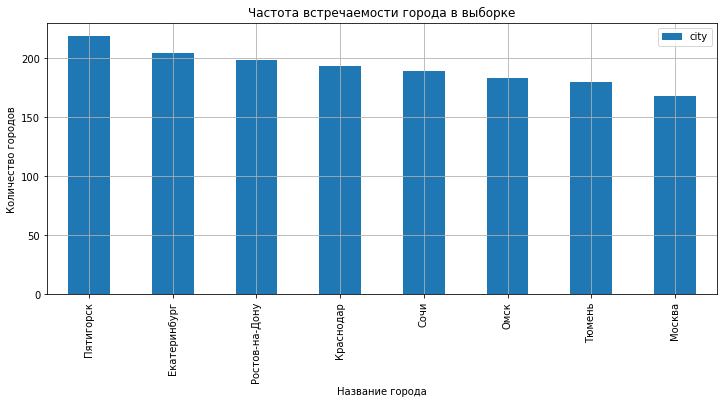

In [24]:
users['city'].value_counts().plot(
    kind='bar',
    grid=True,
    title='Частота встречаемости города в выборке',
    xlabel='Название города',
    ylabel='Количество городов',
    figsize=(12, 5)
)
plt.legend(loc='upper right')
plt.show()

Данные по городам распределены примерно равномерно. Наибольшее число поездок в Пятигорске, наименьшее в Москве.

##### Cоотношение пользователей с подпиской и без подписки

In [25]:
users.head()

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


In [26]:
# выведем процентное соотношение числа пользователей с подпиской и без
users['subscription_type'].value_counts(normalize=True)

free     0.544329
ultra    0.455671
Name: subscription_type, dtype: float64

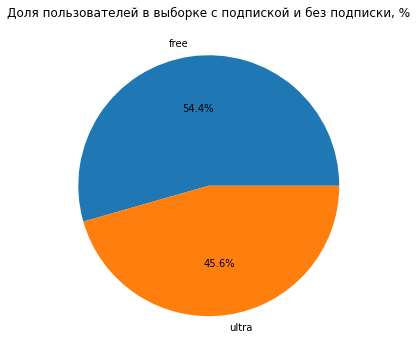

In [27]:
# построим диаграмму
users['subscription_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    title='Доля пользователей в выборке с подпиской и без подписки, %',
    ylabel='',
    figsize=(6,6)
)
plt.show()

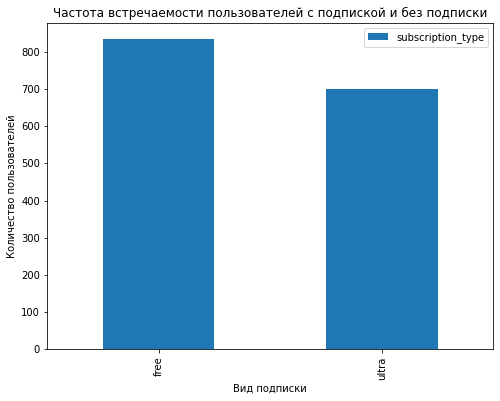

In [28]:
# построим гистограмму с распределение данных по подпискам
users['subscription_type'].value_counts().plot(
    kind='bar',
    title='Частота встречаемости пользователей с подпиской и без подписки',
    xlabel='Вид подписки',
    ylabel='Количество пользователей',
    figsize=(8, 6)
)
plt.legend(loc='upper right')
plt.show()

Большиснтво (54.4%) пользователей пользуются сервисом аренды самокатов без подписки.

##### Возраст пользователей

In [29]:
# Выведем статистику пользователей по возрасту
users['age'].describe()

count    1534.000000
mean       24.903520
std         4.572367
min        12.000000
25%        22.000000
50%        25.000000
75%        28.000000
max        43.000000
Name: age, dtype: float64

Приложение пользуются пользователи в возрасте от 12 до 43 лет.

Средний возраст пользователя - 25 лет.

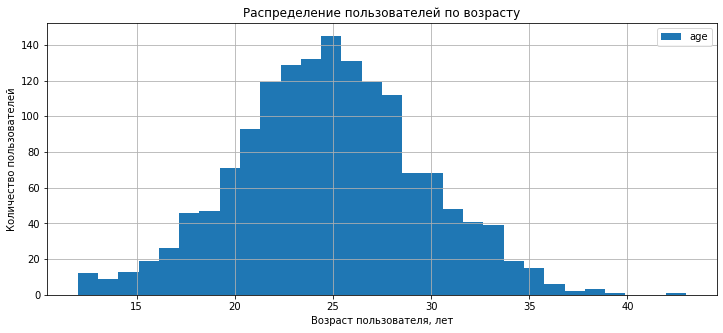

In [30]:
# Выведем распреление пользователей по возрастам в виде гистограммы
users['age'].plot(
    kind='hist',
    bins=30,
    grid=True,
    title='Распределение пользователей по возрасту',
    xlabel='Возраст пользователя, лет',
    figsize=(12, 5)
)
plt.ylabel('Количество пользователей')
plt.xlabel('Возраст пользователя, лет')
plt.legend(loc='upper right')
plt.show()

Распределение пользователей по возрастам имеет вид близкий к нормальному распределению, со средним значением в районе 25 лет. 

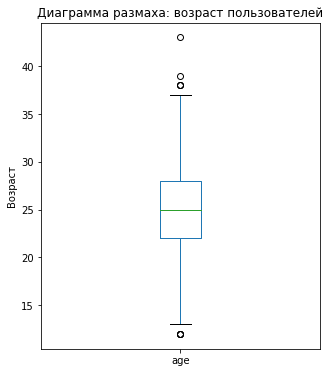

In [31]:
# Построим диаграмму размаха, чтобы оценить распредлеление данных и наличие выбросов
users['age'].plot(kind='box', figsize=(5,6))
plt.title('Диаграмма размаха: возраст пользователей')
plt.ylabel('Количество пользователей')
plt.ylabel('Возраст')
plt.show()

На диаграмме размаха заметные несколько выбросов для значений с возрастом ниже 15 лет и больше 35. 

Видно, что сервисом пользуются как подростки, так и взрослые. Но основаная аудитория - молодые люди в возрасте от 22 до 28 лет.

##### Расстояние, которое пользователь преодолел за одну поездку

In [32]:
rides.head()

,user_id,distance,duration,date,month
0,1,4409.919140,25.599769,2021-01-01,1
1,1,2617.592153,15.816871,2021-01-18,1
2,1,754.159807,6.232113,2021-04-20,4
3,1,2694.783254,18.511000,2021-08-11,8
4,1,4028.687306,26.265803,2021-08-28,8


In [33]:
# # Выведем статистику поездок по расстоянию
rides['distance'].describe()

count    18068.000000
mean      3070.659976
std       1116.831209
min          0.855683
25%       2543.226360
50%       3133.609994
75%       3776.222735
max       7211.007745
Name: distance, dtype: float64

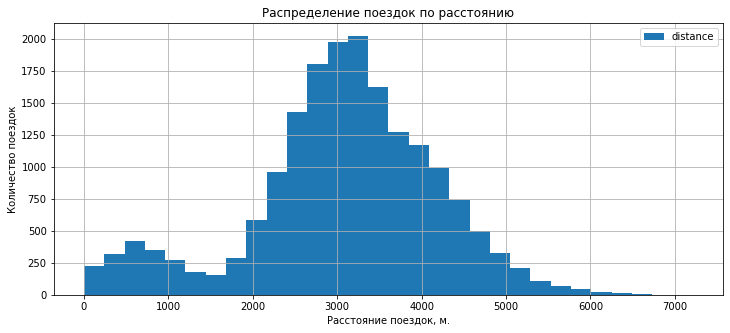

In [34]:
# изобразим распределение дистанций на гистограмме
rides['distance'].plot(
    kind='hist',
    grid=True,
    bins=30,
    title='Распределение поездок по расстоянию',
    figsize=(12, 5)
)
plt.xlabel('Расстояние поездок, м.')
plt.ylabel('Количество поездок')
plt.legend(loc='upper right')
plt.show()

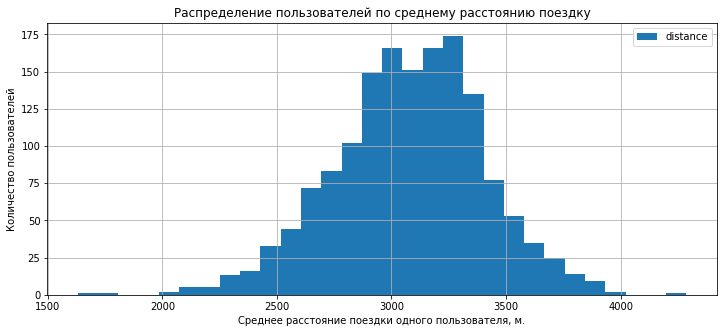

In [35]:
rides.groupby('user_id')['distance'].mean().plot(
    kind='hist',
    grid=True,
    bins=30,
    title='Распределение пользователей по среднему расстоянию поездку',
    figsize=(12, 5)
)
plt.xlabel('Среднее расстояние поездки одного пользователя, м.')
plt.ylabel('Количество пользователей')
plt.legend(loc='upper right')
plt.show()

Средняя поездка пользователя по растоянию около 3км. Распределение поездок по расстоянию имеет распределение близкое к нормальному, однако на графике заметен небольшой пик поездок на короткие дистанции (от 0 до 1000м).

Если построить распределение пользователей по средней дистанции поездки, то данный пик исчезает и распределение пользователей по среднему расстоянию имеет вид нормального распределения.

##### Продолжительность поездок

In [36]:
rides['duration'].describe()

count    18068.000000
mean        17.805011
std          6.091051
min          0.500000
25%         13.597563
50%         17.678395
75%         21.724800
max         40.823963
Name: duration, dtype: float64

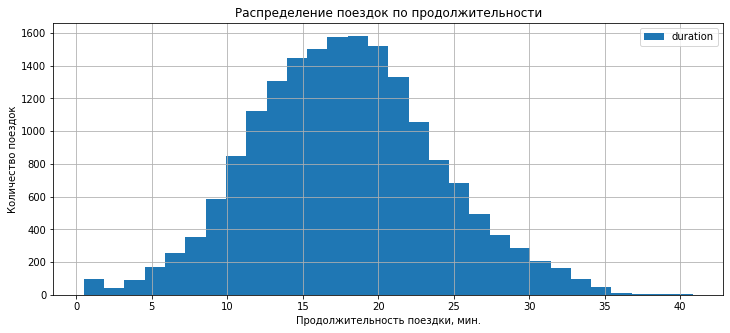

In [37]:
rides['duration'].plot(
    kind='hist',
    grid=True,
    bins=30,
    title='Распределение поездок по продолжительности',
    figsize=(12, 5)
)
plt.xlabel('Продолжительность поездки, мин.')
plt.ylabel('Количество поездок')
plt.legend(loc='upper right')
plt.show()

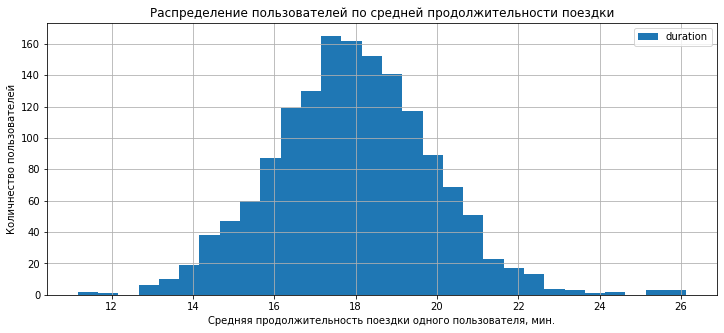

In [38]:
rides.groupby('user_id')['duration'].mean().plot(
    kind='hist',
    grid=True,
    bins=30,
    title='Распределение пользователей по средней продолжительности поездки',
    figsize=(12, 5)
)
plt.xlabel('Средняя продолжительность поездки одного пользователя, мин.')
plt.ylabel('Количнество пользователей')
plt.legend(loc='upper right')
plt.show()

В среднем одна поездка длится около 18 минут.
Распределение поездок по продолжительности и распределение пользователей по средней продолжительности поездки имеют вид нормального распределения.

Аномалий на графиках не заметно

##### Средняя скорость поездки

In [39]:
rides.head(1)

,user_id,distance,duration,date,month
0,1,4409.91914,25.599769,2021-01-01,1


In [40]:
# добавим колонку со средней скоростью поездки в км/ч
rides['average_speed_kmh'] = round((rides['distance'] / 1000) / (rides['duration'] / 60), 2)

In [41]:
rides['average_speed_kmh'].describe()

count    18068.000000
mean        13.785279
std         44.156200
min          0.010000
25%          8.130000
50%         10.250000
75%         12.930000
max        865.320000
Name: average_speed_kmh, dtype: float64

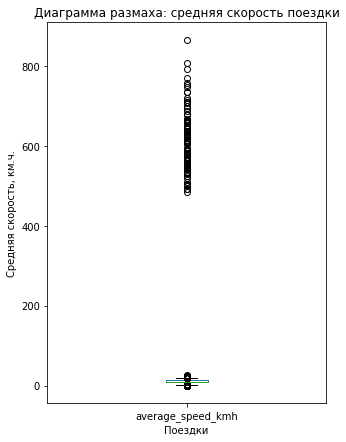

In [42]:
rides['average_speed_kmh'].plot(kind='box', figsize=(5, 7))
plt.title('Диаграмма размаха: средняя скорость поездки')
plt.xlabel('Поездки')
plt.ylabel('Средняя скорость, км.ч.')
plt.show()

В данных есть очень странные поездки на самокате со средней скоростью более 400 км/ч!

Даже если самокаты перевозили по городу на машине, то такие значения выглядят нереально.

In [43]:
rides.query('average_speed_kmh > 400')

,user_id,distance,duration,date,month,average_speed_kmh
6531,701,4196.445201,0.5,2021-08-31,8,503.57
6570,704,4830.824371,0.5,2021-10-14,10,579.70
6680,712,4684.004397,0.5,2021-03-04,3,562.08
6695,713,5215.642710,0.5,2021-02-25,2,625.88
6768,718,5197.436649,0.5,2021-02-11,2,623.69
...,...,...,...,...,...,...
17004,1460,5531.335845,0.5,2021-01-19,1,663.76
17242,1477,6724.932981,0.5,2021-01-12,1,806.99
17314,1483,4445.481070,0.5,2021-03-06,3,533.46
17505,1496,5722.551787,0.5,2021-02-14,2,686.71


In [44]:
# выведем статистику по средним значения по аномальным поездкам в разрезе пользователей 
rides.query('average_speed_kmh > 400').groupby('user_id').mean().describe()

,distance,duration,month,average_speed_kmh
count,90.000000,90.0,90.000000,90.000000
mean,5125.251648,0.5,6.461111,615.030444
std,649.203398,0.0,3.641388,77.903984
min,4030.308008,0.5,1.000000,483.640000
25%,4685.248284,0.5,3.000000,562.230000
50%,5055.798900,0.5,6.500000,606.695000
75%,5488.617698,0.5,9.750000,658.632500
max,7211.007745,0.5,12.000000,865.320000


Заметна явная проблема с регистрацией продолжительности заезда по этим поездки. У всех поездок длительность 0.5 минут

Проверим:

- есть ли у пользователей с аномальными поездками еще поездки. Тогда причина проблемы возможно заключается в техническом сбое программного обеспечения и неверной регистрацией времени. Иначе возможна подозрительная активность пользователей (боты, мошенники и т.д.).
- все поездки на расстояния более 4000 метров. Возможно проблема связаны с регистрацией времени длинных поездок.

In [45]:
strange_user_id = rides.query('average_speed_kmh > 400')['user_id'].unique()
rides.query('user_id in @strange_user_id').groupby('user_id').mean().describe()

,distance,duration,month,average_speed_kmh
count,90.000000,90.000000,90.000000,90.000000
mean,3151.377792,16.148341,6.578955,57.192642
std,313.722073,1.599767,0.853250,16.740088
min,2155.542611,12.119112,4.250000,36.612778
25%,2950.478581,15.020816,6.190625,46.148531
50%,3173.205173,16.194988,6.714286,52.679389
75%,3354.839997,17.368997,7.179087,62.056223
max,3778.123172,20.347897,8.133333,137.376667


У данных пользователей есть и другие поездки - больше похоже на технических сбой. Проверим что с длительностью поездок на расстоянии >4000 метров:

In [46]:
# посмотрим статистику длительности поездок >4000 км (для чистоты исключим из нее аномальные значения)
rides.query('(distance > 4000) and (duration > 1)')['duration'].describe()

count    3383.000000
mean       22.168115
std         5.613283
min        10.246068
25%        18.070076
50%        21.887565
75%        26.007977
max        40.823963
Name: duration, dtype: float64

С длинными поездками тоже все в порядке. 

Установить причину такой ошибки на основе имеющихся данных не представляется возможным. Возможно, имеет место техническая ошибка. Рекомендуется уточнить этот момент у разработчиков сервиса или сотрудников, которые выгружали данные. 

Аномальные данные составляют: 95 значений или 0.5% исходного датасета.

Поскольку аномальные данные представляют собой реальные наблюдения о поездках пользователей и за них была получена оплата, которая анализируется далее в исследовании, то аномальные данные были оставлены в выборке как есть.

<u>*NB. Вследствие некорректного учета времени поездки, компания могла недополучить доходы от данных поездок, т.к. при правильно учете длительность поездок составила бы более 0.5 минуты и в компании применяется поминутная тарификация.*</u>

Попробуем оценить приблизительный размер недополученной выручки сервисом вследствие ошибки.

In [47]:
# Запишем аномальные поездки в переменную strange_rides для передачи коллегам, с целью установления и устранения причин аномалии.
strange_rides = rides[rides['average_speed_kmh'] > 400]

strange_rides.describe()

,user_id,distance,duration,month,average_speed_kmh
count,95.000000,95.000000,95.0,95.000000,95.000000
mean,1092.210526,5113.176549,0.5,6.484211,613.581474
std,244.028551,658.254104,0.0,3.709858,78.990014
min,701.000000,4030.308008,0.5,1.000000,483.640000
25%,901.000000,4611.510820,0.5,3.000000,553.380000
50%,1069.000000,5052.769411,0.5,6.000000,606.330000
75%,1310.500000,5488.459099,0.5,10.000000,658.615000
max,1524.000000,7211.007745,0.5,12.000000,865.320000


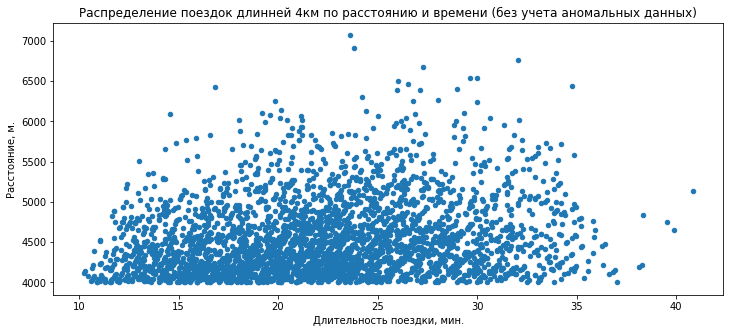

In [48]:
# посмотрим как распределены нормальные поездки на расстояние >4000 м
rides.query('(average_speed_kmh < 400) and (distance > 4000)')[['distance', 'duration']].plot(
    kind='scatter',
    y='distance',
    x='duration',
    title='Распределение поездок длинней 4км по расстоянию и времени (без учета аномальных данных)',
    xlabel='Длительность поездки, мин.',
    ylabel='Расстояние, м.',
    figsize=(12, 5)
)
plt.show()

Поездки распределены "нормально", какой-то явной зависимости времени от расстояния на графике не заметно. Для оценки размера недополученной выручки возьмем медиану по таким же поездкам на расстоянии >4000 м.

In [49]:
# медианная длительность поездок на расстоянии > 4000 м., округленная кверху
median_time = int(np.ceil(rides.query('(average_speed_kmh < 400) and (distance > 4000)')['duration'].median()))
median_time

22

In [50]:
# подтянем в таблицу информацию о пользователях и подписках
strange_rides = strange_rides.merge(users, how='left', on='user_id').merge(subscriptions, how='left', on='subscription_type')

In [51]:
strange_rides.head()

,user_id,distance,duration,date,month,average_speed_kmh,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
0,701,4196.445201,0.5,2021-08-31,8,503.57,Иван,31,Екатеринбург,free,8,50,0
1,704,4830.824371,0.5,2021-10-14,10,579.70,Мирон,29,Ростов-на-Дону,free,8,50,0
2,712,4684.004397,0.5,2021-03-04,3,562.08,Дарья,28,Москва,free,8,50,0
3,713,5215.642710,0.5,2021-02-25,2,625.88,Святослав,30,Краснодар,free,8,50,0
4,718,5197.436649,0.5,2021-02-11,2,623.69,Владислава,31,Москва,free,8,50,0


In [52]:
# в колонке shortfall_revenue посчитаем величину недополученного дохода от каждой поездки
strange_rides['shortfall_revenue'] = (median_time - np.ceil(strange_rides['duration']).astype('int')) * strange_rides['minute_price']
strange_rides['shortfall_revenue'].sum()

15960

Недополученный доход от аномальных поездок по выборке составил около 16 тыс. рублей.

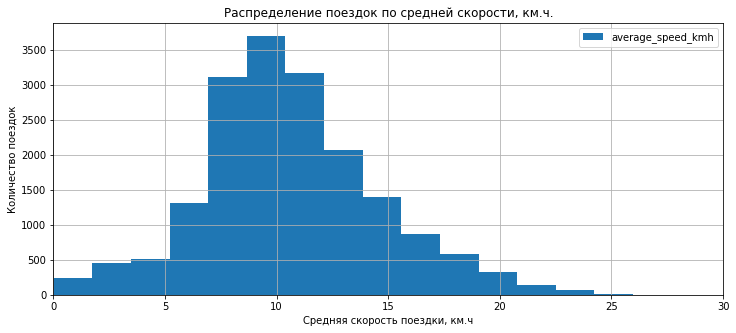

In [53]:
rides['average_speed_kmh'].plot(
    kind='hist',
    grid=True,
    bins=500,
    title='Распределение поездок по средней скорости, км.ч.',
    figsize=(12, 5)
)
plt.xlim(0, 30)
plt.xlabel('Средняя скорость поездки, км.ч')
plt.ylabel('Количество поездок')
plt.legend(loc='upper right')
plt.show()

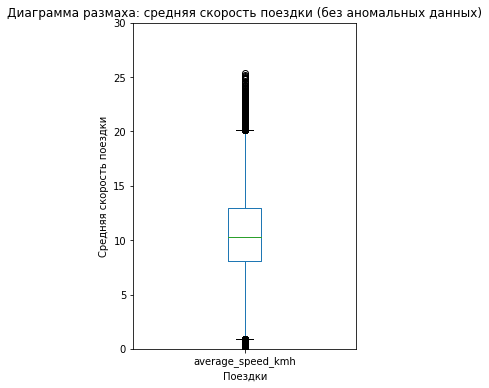

In [54]:
rides['average_speed_kmh'].plot(kind='box', figsize=(4, 6))
plt.ylim(0, 30)
plt.title('Диаграмма размаха: средняя скорость поездки (без аномальных данных)')
plt.xlabel('Поездки')
plt.ylabel('Средняя скорость поездки')
plt.show()

Если не учитывать аномальные поездки, то распределение по скоростям имеет вид нормального распеределения.

##### Выводы

В ходе исследовательского анализа данных были получены следующие выводы:

1. Данные по городам распределены примерно равномерно. Наибольшее число поездок в Пятигорске, наименьшее в Москве.
2. Большиснтво (54.4%) пользователей пользуются сервисом аренды самокатов без подписки.
3. Распределение пользователей по возрастам имеет вид близкий к нормальному распределению, со средним значением в районе 25 лет. Ооснованая аудитория сервиса - молодые люди в возрасте от 22 до 28 лет.
4. Средняя поездка пользователя по растоянию составляет около 3км. Распределение поездок по расстоянию имеет распределение близкое к нормальному, однако на графике заметен небольшой пик поездок на короткие дистанции (от 0 до 1000м). Если построить распределение пользователей по средней дистанции поездки, то данный пик исчезает и распределение пользователей по среднему расстоянию имеет вид нормального распределения.
5. Средняя продолжительность одной поездки составляет около 18 минут. Распределение поездок по продолжительности и распределение пользователей по средней продолжительности поездки имеют вид нормального распределения.
6. В данных есть поездки на самокате (95 шт) с аномально высокой скоростью передвижения (>400 км/ч!). Установить причину такой аномалии на основе имеющихся данных не представляется возможным. Возможно, имеет место техническая ошибка. Рекомендуется уточнить этот момент у разработчиков сервиса или сотрудников, которые выгружали данные.

#### Шаг 4. Объединение данных

##### Объединим данные о пользователях, поездках и подписках в один датафрейм.

In [55]:
users.shape

(1534, 5)

In [56]:
rides.head()

,user_id,distance,duration,date,month,average_speed_kmh
0,1,4409.919140,25.599769,2021-01-01,1,10.34
1,1,2617.592153,15.816871,2021-01-18,1,9.93
2,1,754.159807,6.232113,2021-04-20,4,7.26
3,1,2694.783254,18.511000,2021-08-11,8,8.73
4,1,4028.687306,26.265803,2021-08-28,8,9.20


In [57]:
subscriptions.head()

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


In [58]:
df = (rides
.merge(users, on='user_id', how='left')
.merge(subscriptions, on='subscription_type', how='left')
)

In [59]:
df.head()

,user_id,distance,duration,date,month,average_speed_kmh,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,4409.919140,25.599769,2021-01-01,1,10.34,Кира,22,Тюмень,ultra,6,0,199
1,1,2617.592153,15.816871,2021-01-18,1,9.93,Кира,22,Тюмень,ultra,6,0,199
2,1,754.159807,6.232113,2021-04-20,4,7.26,Кира,22,Тюмень,ultra,6,0,199
3,1,2694.783254,18.511000,2021-08-11,8,8.73,Кира,22,Тюмень,ultra,6,0,199
4,1,4028.687306,26.265803,2021-08-28,8,9.20,Кира,22,Тюмень,ultra,6,0,199


In [60]:
df['subscription_fee'].sum()

1293500

In [61]:
# проверим соответствие размерностей получившейся и исходной таблиц
print(f'Размерность исходной таблицы rides: {rides.shape},\n\
Размерность получившейся таблицы df: {df.shape}\n')

Размерность исходной таблицы rides: (18068, 6),
Размерность получившейся таблицы df: (18068, 13)



In [62]:
# проверим есть ли пропуски в результирующей таблице
df.isna().sum()

user_id              0
distance             0
duration             0
date                 0
month                0
average_speed_kmh    0
name                 0
age                  0
city                 0
subscription_type    0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64

##### Разделим датафрейм с поездками на два: c данными о пользователях без подписки и с подпиской

In [63]:
df_subs = df.query('subscription_type == "ultra"')
df_free = df.query('subscription_type == "free"')

In [64]:
df_subs.head()

,user_id,distance,duration,date,month,average_speed_kmh,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,4409.919140,25.599769,2021-01-01,1,10.34,Кира,22,Тюмень,ultra,6,0,199
1,1,2617.592153,15.816871,2021-01-18,1,9.93,Кира,22,Тюмень,ultra,6,0,199
2,1,754.159807,6.232113,2021-04-20,4,7.26,Кира,22,Тюмень,ultra,6,0,199
3,1,2694.783254,18.511000,2021-08-11,8,8.73,Кира,22,Тюмень,ultra,6,0,199
4,1,4028.687306,26.265803,2021-08-28,8,9.20,Кира,22,Тюмень,ultra,6,0,199


In [65]:
df_free.head()

,user_id,distance,duration,date,month,average_speed_kmh,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
6500,700,2515.690719,14.944286,2021-01-02,1,10.10,Айдар,22,Омск,free,8,50,0
6501,700,846.932642,16.234663,2021-02-01,2,3.13,Айдар,22,Омск,free,8,50,0
6502,700,4004.434142,20.016628,2021-02-04,2,12.00,Айдар,22,Омск,free,8,50,0
6503,700,1205.911290,9.782872,2021-02-10,2,7.40,Айдар,22,Омск,free,8,50,0
6504,700,3047.379435,17.427673,2021-02-14,2,10.49,Айдар,22,Омск,free,8,50,0


##### Визуализируем информацию о расстоянии и времени поездок для пользователей обеих категорий.

**Расстояния:**

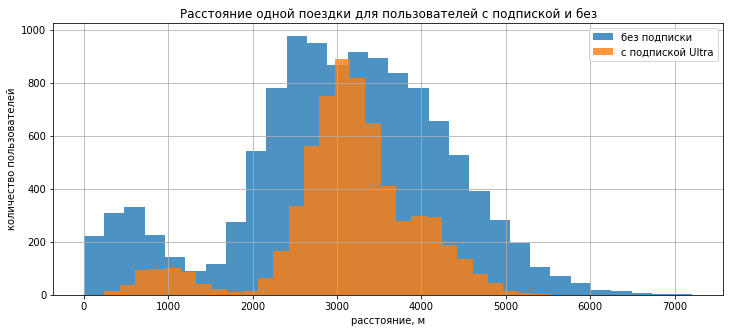

In [66]:
ax = df_free['distance'].plot(kind = 'hist', grid=True, figsize = (12,5), bins = 30, label='без подписки', alpha=0.8)
ax = df_subs['distance'].plot(kind = 'hist', grid=True, figsize = (12,5), bins = 30, label='с подпиской Ultra', alpha=0.8)
plt.title('Расстояние одной поездки для пользователей с подпиской и без')
plt.xlabel('расстояние, м')
plt.ylabel('количество пользователей')
plt.legend(loc='upper right')
plt.show()

Оранжевое и синее распределения значительно перекрываются в центральной части графика, что указывает на схожие типичные расстояния поездок для обеих групп пользователей. Пик обоих распределений находится примерно в одном и том же диапазоне (около 3 км), что может говорить о том, что среднее расстояние поездок для обеих групп сходно.

**Длинные поездки:**
- Пользователи без подписки (синий цвет) демонстрируют больше поездок на большие расстояния по сравнению с пользователями с подпиской Ultra. Это видно из большего количества синих столбцов в правой части графика.

**Короткие поездки:**
- В левой части графика также видно, что пользователи без подписки совершают больше коротких поездок по сравнению с пользователями с подпиской Ultra.

    
В целом, пользователи без подписки имеют более равномерное распределение поездок по различным расстояниям, в то время как пользователи с подпиской Ultra имеют более концентрированное распределение вокруг среднего значения.

Эти наблюдения могут указывать на то, что пользователи без подписки более склонны к разнообразным поездкам, в то время как пользователи с подпиской Ultra чаще совершают поездки среднего расстояния.

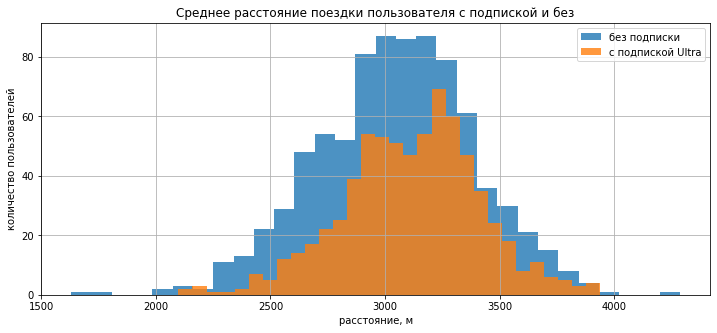

In [67]:
ax = (df_free
      .groupby('user_id')['distance']
      .mean()
      .plot(
          kind = 'hist',
          grid=True, 
          figsize = (12,5),
          bins = 30,
          label='без подписки',
          alpha = 0.8)
     )
ax = (df_subs
      .groupby('user_id')['distance']
      .mean()
      .plot(
          kind = 'hist',
          grid=True,
          figsize = (12,5),
          bins = 30,
          label='с подпиской Ultra',
          alpha = 0.8)
     )
plt.title('Среднее расстояние поездки пользователя с подпиской и без')
plt.xlabel('расстояние, м')
plt.ylabel('количество пользователей')
plt.legend(loc='upper right')
plt.show()

Распределение пользователей с подпиской и без по среднему расстоянию поездку похожи между собой и имеют виду нормального распределения. 

Графики равномерно распределены вокруг приблизительно одних и тех же средних значений, что свидетельствует о том, что среднее растояние поездки пользователей с подпиской и без подписки существенно не различаются

**Продолжительность:**

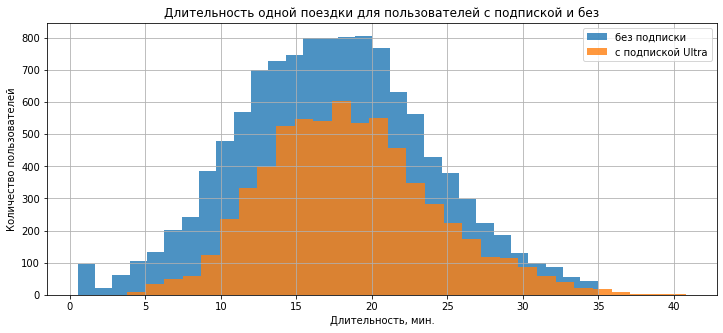

In [68]:
ax = df_free['duration'].plot(kind = 'hist', grid=True, figsize = (12,5), bins = 30, label='без подписки', alpha=0.8)
ax = df_subs['duration'].plot(kind = 'hist', grid=True, figsize = (12,5), bins = 30, label='с подпиской Ultra', alpha=0.8)
plt.title('Длительность одной поездки для пользователей с подпиской и без')
plt.xlabel('Длительность, мин.')
plt.ylabel('Количество пользователей')
plt.legend(loc='upper right')
plt.show()

Распределения длительности поездок пользователей без подписки и с подпиской имеют вид нормального распределения. Значения распеределены равномерно вокруг диапазона средних значений в районе 15-20 минут.

*NB. У пользователей без подписок на графике выше был заметен небольшой пик очень коротких поездок (95 шт) в районе до 1 минуты. Этоn пик сформирован в основном за счет аномальных поездок со скоростью >400 км.ч. (время каждой такой поездки 0.5 минуты)*

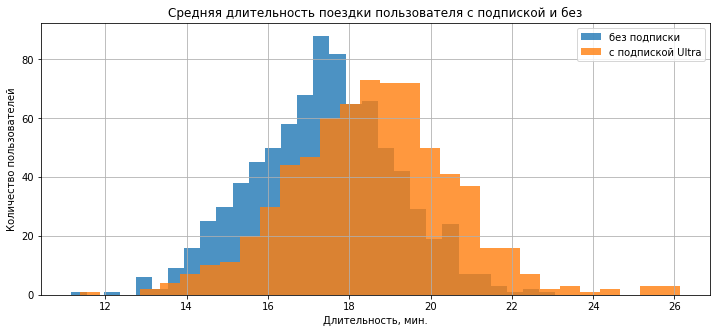

In [69]:
ax = (df_free
      .groupby('user_id')['duration']
      .mean()
      .plot(
          kind = 'hist',
          grid=True, 
          figsize = (12,5),
          bins = 30,
          label='без подписки',
          alpha = 0.8)
     )
ax = (df_subs
      .groupby('user_id')['duration']
      .mean()
      .plot(
          kind = 'hist',
          grid=True,
          figsize = (12,5),
          bins = 30,
          label='с подпиской Ultra',
          alpha = 0.8)
     )
plt.title('Средняя длительность поездки пользователя с подпиской и без')
plt.xlabel('Длительность, мин.')
plt.ylabel('Количество пользователей')
plt.legend(loc='upper right')
plt.show()

График оранжевого распределения (средняя продолжительность поездки пользователей с подпиской) смешена вправо относительно синего распеределения (без подписки).

Это значит, что в в среднем пользователи с подпиской Ultra тратят больше времени на одну поездку, чем пользователи без подписки.

##### Выводы

На данном было выполнено объединение данных о пользователях, поездках и подписках в один датафрейм. Затем датафрейм с поездками был разделен на два поддатафрейма: один содержал данные о пользователях без подписки, а другой - с подпиской Ultra.

После этого были построены графики и проведен визуальный анализ информации о расстоянии и времени поездок для обеих категорий пользователей.

По результатам анализа были сделаны следующие наблюдения:

- Распределение расстояний одной поездки для пользователей с подпиской Ultra и без подписки похожи на нормальное распределение. При этом пользователи без подписки имеют более равномерное распределение поездок по различным расстояниям, а пользователи с подпиской Ultra имеют более концентрированное распределение вокруг среднего значения. Эти наблюдения могут указывать на то, что пользователи без подписки более склонны к разнообразным поездкам, в то время как пользователи с подпиской Ultra чаще совершают поездки среднего расстояния.
- Распределения длительности поездок пользователей без подписки и с подпиской имеют вид нормального распределения. Значения распеределены равномерно вокруг диапазона средних значений в районе 15-20 минут.

#### Шаг 5. Подсчёт выручки

##### Создадим датафрейм с агрегированными данными о поездках

In [70]:
df.head(1)

,user_id,distance,duration,date,month,average_speed_kmh,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,4409.91914,25.599769,2021-01-01,1,10.34,Кира,22,Тюмень,ultra,6,0,199


In [71]:
# округлим продолжительность каждой поездки в каждой строке исходного датафрейма до следующего целого числа
df['duration'] = np.ceil(df['duration']).astype('int')

In [72]:
# создадим сводную таблицу
stats = df.pivot_table(index=['user_id', 'month'], values=['distance', 'duration'], aggfunc={'distance' : ['sum', 'count'], 'duration' : 'sum'})
stats.columns = ['count', 'distance_total', 'duration_total']

In [73]:
stats.reset_index(inplace=True)
stats

,user_id,month,count,distance_total,duration_total
0,1,1,2,7027.511294,42
1,1,4,1,754.159807,7
2,1,8,2,6723.470560,46
3,1,10,2,5809.911100,32
4,1,11,3,7003.499363,56
...,...,...,...,...,...
11326,1534,6,2,3409.468534,26
11327,1534,8,2,7622.453034,48
11328,1534,9,1,4928.173852,23
11329,1534,11,4,13350.015305,78


##### Добавим столбец с помесячной выручкой, которую принёс каждый пользователь.

In [74]:
# добавим в таблицу колонки с типом и условиями подписки
stats = stats.merge(users[['user_id', 'subscription_type']], on='user_id', how='left')
stats = stats.merge(subscriptions, on='subscription_type', how='left')

In [75]:
# добавим колонку с месячным доходом
stats['monthly_revenue'] = (
    stats['start_ride_price'] * stats['count'] +
    stats['minute_price'] * stats['duration_total'] +
    stats['subscription_fee']
).astype('int')

In [76]:
stats.head()

,user_id,month,count,distance_total,duration_total,subscription_type,minute_price,start_ride_price,subscription_fee,monthly_revenue
0,1,1,2,7027.511294,42,ultra,6,0,199,451
1,1,4,1,754.159807,7,ultra,6,0,199,241
2,1,8,2,6723.470560,46,ultra,6,0,199,475
3,1,10,2,5809.911100,32,ultra,6,0,199,391
4,1,11,3,7003.499363,56,ultra,6,0,199,535


##### Выводы

На шаге 5 был выполнен подсчёт ежемесячной выручки на основе агрегированных данных о поездках пользователей.

- Данные о поездках пользователей были успешно агрегированы по пользователям и месяцам.
- Был добавлен столбец с помесячной выручкой, учитывающей условия оплаты для подписчиков и пользователей без подписки.
- Продолжительность поездки была округлена до следующего целого числа, что позволило корректно рассчитать выручку.

#### Шаг 6. Проверка гипотез

##### Гипотеза 1
Проверим тратят ли пользователи с подпиской больше времени на поездки? Если да, то пользователи с подпиской могут быть «выгоднее» для компании.

Используем исходные данные о продолжительности каждой сессии — отдельно для подписчиков и тех, у кого нет подписки.

- H0 (нулевая гипотеза) = среднее время поездок пользователей с подписками и без подписок равны.
- H1 (альтернативная гипотеза) = среднее время поездок пользователей с подписками больше чем у пользователей без подписок

In [77]:
print(f'Средняя продолжительность поездки пользователей без подписок:', round(df_free['duration'].mean(), 2), 'минут')
print(f'Средняя продолжительность поездки пользователей с подпискй Ultra:', round(df_subs['duration'].mean(), 2), 'минут')

Средняя продолжительность поездки пользователей без подписок: 17.39 минут
Средняя продолжительность поездки пользователей с подпискй Ultra: 18.54 минут


In [78]:
# выбранный уровень статистической значимости
alpha = 0.05
print(f"Уровень статистической значимости: {alpha * 100}%")

# проведем односторонний ttest
results = st.ttest_ind(df_subs['duration'], df_free['duration'], alternative='greater')

#выведем полученное значение p-value
print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

Уровень статистической значимости: 5.0%
p-value: 1.2804098316645618e-34
Отвергаем нулевую гипотезу


In [79]:
# выбранный уровень статистической значимости
alpha = 0.01
print(f"Уровень статистической значимости: {alpha * 100}%")

# проведем односторонний ttest
results = st.ttest_ind(df_subs['duration'], df_free['duration'], alternative='greater')

#выведем полученное значение p-value
print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

Уровень статистической значимости: 1.0%
p-value: 1.2804098316645618e-34
Отвергаем нулевую гипотезу


<u>Результат проверки </u>: На имеющихся данных, при уровне значимости 1% (уровне доверия 99%) есть основания отвергнуть нулевую гипотезу (H0) о равенстве среднего времени поездок пользователей с подписками и без подписок в пользу альтернативной гипотезы (H1) о том, что пользователи с подпиской тратят больше времени на поездки, чем пользователи без подписки.

##### Гипотеза 2

Расстояние одной поездки в 3130 метров — оптимальное с точки зрения износа самоката. 

Поскольку большее расстояние приводит к повышенному износу самоката, проверим верно ли утверждение, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, превышает 3130 метров?

- H0 (нулевая гипотеза) = среднее расстояние, которое проезжают пользователи с подпиской за одну поездку равно 3130 метров.
- H1 (альтернативная гипотеза) = среднее расстояние, которое проезжают пользователи с подпиской за одну поездку превышает 3130 метров.

In [80]:
print(f'Средняя расстояние поездки пользователей с подпискй Ultra:', round(df_subs['distance'].mean(), 2), 'км.')

Средняя расстояние поездки пользователей с подпискй Ultra: 3115.45 км.


In [81]:
# выбранный уровень статистической значимости
value = 3130
alpha = 0.05
print(f"Уровень статистической значимости: {alpha * 100}%")

# проведем односторонний ttest
results = st.ttest_1samp(df_subs['distance'], value, alternative='greater')

#выведем полученное значение p-value
print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

Уровень статистической значимости: 5.0%
p-value: 0.9195368847849785
Не получилось отвергнуть нулевую гипотезу


In [82]:
# выбранный уровень статистической значимости
value = 3130
alpha = 0.01
print(f"Уровень статистической значимости: {alpha * 100}%")

# проведем односторонний ttest
results = st.ttest_1samp(df_subs['distance'], value, alternative='greater')

#выведем полученное значение p-value
print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

Уровень статистической значимости: 1.0%
p-value: 0.9195368847849785
Не получилось отвергнуть нулевую гипотезу


Выборочное среднее равно 3115.45 отличается от 3130 — предположенного в нулевой гипотезе значения. Но это отличие недостаточно велико, чтобы сделать вывод о том, что истинное среднее генеральной совокупности, из которой взята выборка, отличается от 3130 — и при уровне статистической значимости 1%, и при 5%.

<u>Результаты проверки</u>: На имеющихся данных, при уровне значимости 1% (уровне доверия 99%) нет оснований отвергнуть нулевую гиппотезу (H0) о том, что среднее расстояние, которое проезжают пользователи с подпиской, равно 3140 км.

##### Гипотеза 3

Проверим гипотезу о том, будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки.

- H0 (нулевая гиппоотеза) = помесячная выручка от пользователей с подпиской по месяцам равна выручке от пользователей без подписки.
- H1 (альтернативная гипотеза) = помесячная выручка от пользователей с подпиской по месяцам выше выручки от пользователей без подписки.

In [83]:
# выбранный уровень статистической значимости
alpha = 0.05
print(f"Уровень статистической значимости: {alpha * 100}%")

# проведем односторонний ttest
results = st.ttest_ind(
    stats.query('subscription_type == "ultra"')['monthly_revenue'], 
    stats.query('subscription_type == "free"')['monthly_revenue'], 
    alternative='greater')

#выведем полученное значение p-value
print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

Уровень статистической значимости: 5.0%
p-value: 1.8850394384715216e-31
Отвергаем нулевую гипотезу


In [84]:
# выбранный уровень статистической значимости
alpha = 0.01
print(f"Уровень статистической значимости: {alpha * 100}%")

# проведем односторонний ttest
results = st.ttest_ind(
    stats.query('subscription_type == "ultra"')['monthly_revenue'], 
    stats.query('subscription_type == "free"')['monthly_revenue'], 
    alternative='greater')

#выведем полученное значение p-value
print('p-value:', results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

Уровень статистической значимости: 1.0%
p-value: 1.8850394384715216e-31
Отвергаем нулевую гипотезу


<u>Результаты проверки</u>: На имеющихся данных, при уровне значимости 1% (уровне доверия 99%) есть достаточно оснований, чтобы отвергнуть нулевую гиппотезу (H0) о том, что помесячная выручка от пользователей с подпиской и без подписки равны. Есть основания говорить о том, что помесячная выручка от пользователей с подпиской по месяцам выше выручки от пользователей без подписки.

##### Гипотеза 4

Представим такую ситуацию: техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Она надеется, что из-за этого количество обращений в техподдержку значимо снизилось. Некоторый файл содержит для каждого пользователя данные о количестве обращений до обновления и после него. 

Какой тест вам понадобился бы для проверки этой гипотезы?

Поскольку в данном случае мы имеем дело с двумя парными(зависимыми) выборками, то для проверки гипотезы можно применить левосторонний t-test о равенстве среднего значения генеральной совокупности до и после изменений. 

Для проверки гипотезы нужно два набора данных с показателеми тех же пользователей до и после обновления.

В данном случае нулевая и альтернативная гипотеза могут быть сформулированы следующим образом:

- H0 (нулевая гипотеза) = количество обращений в техподдержку до и после обновления не изменилось.
- H1 (альтернативная гипотеза) = количество обращений в техподдержку после обновлений стало меньше.


Результаты теста, можно получить и сохранить в переменной `results` следующим образом:

- results = st.ttest_rel(`выборка_до_изменений`, `выборка_после_изменений`, alernative='less') 

если p-value, рассчитанный в результате теста окажется ниже чем уровень стат. значимости, заданный в исследовании, то есть основания утверждать о правильности альтернативной гипотезы (H1).

##### Выводы

На Шаге 6 были проверены следующие гипотезы и сделаны соответствующие выводы:

**1. Гипотеза 1:**

- Нулевая гипотеза (H0): Среднее время поездок пользователей с подпиской и без подписки равны.
- Альтернативная гипотеза (H1): Среднее время поездок пользователей с подпиской больше, чем у пользователей без подписки.
- Результат: Нулевая гипотеза отвергнута на уровнях статистической значимости 5% и 1%. Это значит, есть основания утверждать, что пользователи с подпиской тратят в среднем больше времени на поездки, чем пользователи без подписки. 

**2. Гипотеза 2:**

- Нулевая гипотеза (H0): Среднее расстояние поездки пользователей с подпиской равно 3130 метров.
- Альтернативная гипотеза (H1): Среднее расстояние поездки пользователей с подпиской превышает 3130 метров.
- Результат: Не удалось отвергнуть нулевую гипотезу на уровнях статистической значимости 5% и 1%. Это значит, что нет оснований утверждать, что среднее расстояние поездки пользователей с подпиской превышает 3130 метров.

**3. Гипотеза 3:**

- Нулевая гипотеза (H0): Помесячная выручка от пользователей с подпиской равна выручке от пользователей без подписки.
- Альтернативная гипотеза (H1): Помесячная выручка от пользователей с подпиской выше, чем выручка от пользователей без подписки.
- Результат: Нулевая гипотеза отвергнута на уровне статистической значимости 5% и 1%. Это значит, что есть основания утверждать, что помесячная выручка от пользователей с подпиской по месяцам выше, чем у пользователей без подписки.


**4. Гипотеза 4:**
- Для проверки гипотезы о снижении количества обращений в техподдержку после обновления серверов мобильного приложения можно использовать тест, который позволяет сравнить две связанные выборки. Для этого можно исподльзовать парногы t-теста для сравнения количества обращений каждого пользователя до и после обновления серверов. Это позволит определить, есть ли значимое снижение обращений в техподдержку после обновления.

#### Шаг 7. Распределения

##### Акция с раздачей промокодов

Отделу маркетинга GoFast поставили задачу: нужно провести акцию с раздачей промокодов на один бесплатный месяц подписки, в рамках которой как минимум 100 существующих клиентов должны продлить эту подписку. То есть по завершении периода действия подписки пользователь может либо отказаться от неё, либо продлить, совершив соответствующий платёж.

Эта акция уже проводилась ранее и по итогу выяснилось, что после бесплатного пробного периода подписку продлевают 10% пользователей.

Выясним, какое минимальное количество промокодов нужно разослать, чтобы вероятность не выполнить план была примерно 5%.

Для этого подберем параметры распределения, описывающего эту ситуацию, построим график распределения и сформулируем ответ на вопрос о количестве промокодов.

Для описания результатов этого эксперимента лучше всего подойдет биноминальное распределение, т.к.:

- Проводится фиксированное число попыток n.
- Каждая попытка — простой эксперимент Бернулли ровно с двумя исходами (продлил подписку или нет).
- Вероятность успеха p одинакова для всех n попыток (p=0.01).
- Попытки независимы между собой (подписка одного клиента не влияет на вероятность подписки другого).

In [85]:
k = 100
n = 1  # Изначально устанавливаем n равным 1
p = 0.1 # вероятность что пользователь подпишется

Q = 0.05 # Вероятность не выполнить план

result = 1.0  # Изначально устанавливаем результат больше 0.05, чтобы запустить цикл

while result > Q:
    n += 1
    distr = st.binom(n, p)
    result = distr.cdf(k)

print("Подобранное значение n:", n)
print("Результат:", result)

Подобранное значение n: 1172
Результат: 0.04954795210203071


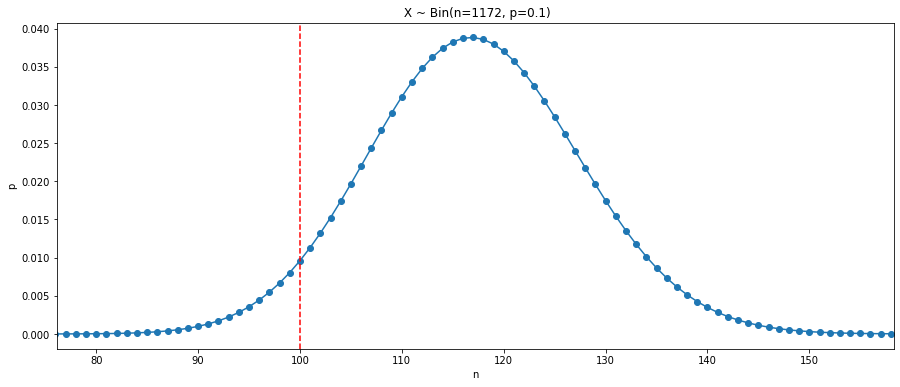

In [86]:
x = range(n+1)
pmf = st.binom.pmf(x, n, p)

plt.figure(figsize=(15, 6))  # Задаем размеры фигуры (ширина=10, высота=6)
plt.plot(x, pmf, marker='o')
plt.axvline(x=k, color='r', linestyle='--', label='100 клинтов с подпиской')
plt.xlabel('n')
plt.ylabel('p')
plt.xlim(n*p - 4*st.binom.std(n, p), n*p + 4*st.binom.std(n, p))
plt.title(f' X ~ Bin(n={n}, p={p})')
plt.show()

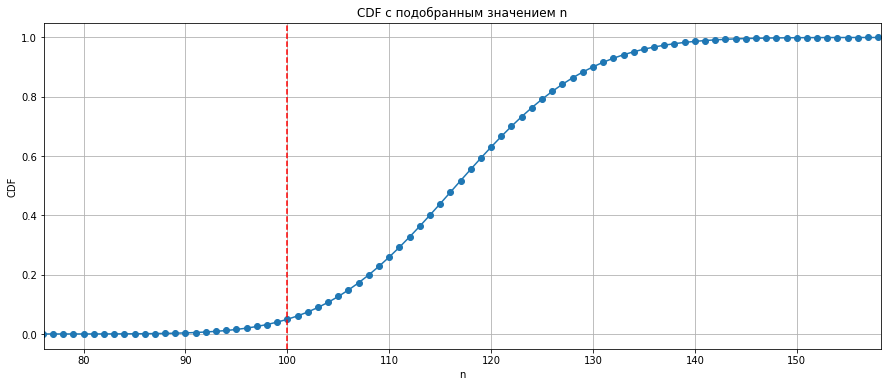

In [87]:
cdf = distr.cdf(x)

plt.figure(figsize=(15, 6))  # Задаем размеры фигуры (ширина=10, высота=6)
plt.plot(x, cdf, marker='o')
plt.axvline(x=k, color='r', linestyle='--', label='100 клинтов с подпиской')
plt.xlabel('n')
plt.ylabel('CDF')
plt.title('CDF с подобранным значением n')
plt.xlim(n*p - 4*st.binom.std(n, p), n*p + 4*st.binom.std(n, p))
plt.grid(True)
plt.show()

Минимальное количество промокодов должно быть около 1172, чтобы вероятность не выполнить план составляла менее 5%.

##### Рассылка push-уведомлений

Отдел маркетинга рассылает клиентам push-уведомления в мобильном приложении. Клиенты могут открыть его или не открывать. Известно, что уведомления открывают около 40% получивших клиентов. Отдел планирует разослать 1 млн уведомлений. 

Так как n=1000000 достаточно велико, а p=0.4 близко к 0.5, то форма графика биномиального распределения должна быть симметрична (без отсечений) и максимально приближена к графику нормального распределения. 

С помощью аппроксимации построим примерный график распределения и оценим вероятность того, что уведомление откроют не более 399,5 тыс. пользователей.

Биноминальное распределение в данном случе задавалось бы следующим образом:
- X ~ Bin(n=1000000, p=0.04)

Для апроксимации биноминального распределения нормальным необходимо рассчитать параметры нормального распределения

- X ~ N(mu, sigma)


Если промежуток от математического ожидания биномиального распределения плюс-минус три его стандартных отклонения лежит в пределах от 0 до n, то аппроксимацию можно
использовать.

In [88]:
# рассчитаем параметры для задания нормального распределения и оценим корректность использования такой апроксимации
n = 1000000
p = 0.4

value = 399500

mu = n*p
sigma = (n*p*(1-p))**0.5

print(f'Математическое ожидание: {mu}')
print(f'Стандартное отклонение: {sigma}')

if ((mu-3*sigma) > 0) and ((mu+3*sigma) < n):
    print('Использовать апроксимацию нормальным распределение корректно')
else:
    print('Использовать апроксимацию нормальным распределение некорректно')

Математическое ожидание: 400000.0
Стандартное отклонение: 489.89794855663564
Использовать апроксимацию нормальным распределение корректно


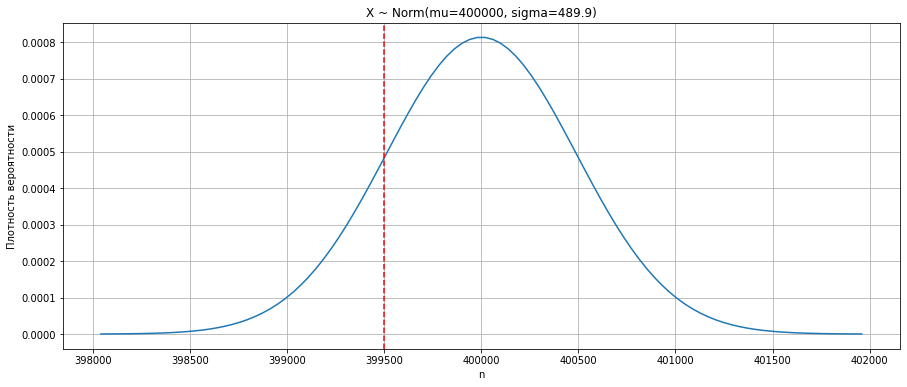

In [89]:
# зададим номальное распределение
distr = st.norm(mu, sigma)

# построим график в пределах +-4 sigma
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 100)
y = distr.pdf(x)

plt.figure(figsize=(15, 6))  # Задаем размеры фигуры (ширина=10, высота=6)
plt.plot(x, y)
plt.axvline(x=value, color='r', linestyle='--', label=value)
plt.xlabel('n')
plt.ylabel('Плотность вероятности')
plt.title(f'X ~ Norm(mu={int(mu)}, sigma={round(sigma,2)})')
plt.grid(True)
plt.show()

In [90]:
result = distr.cdf(value)
print(f'Вероятность что push-уведомления откроют не более 399,5 тыс. пользователей: {round(result*100, 2)}%')

Вероятность что push-уведомления откроют не более 399,5 тыс. пользователей: 15.37%


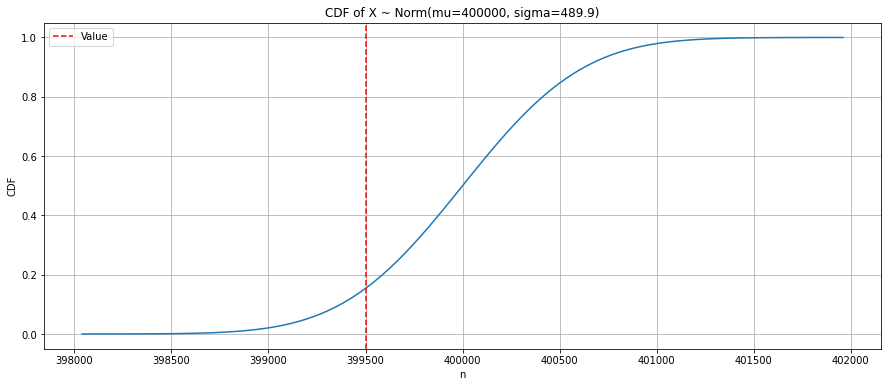

In [91]:
z = distr.cdf(x)

plt.figure(figsize=(15, 6))  # Задаем размеры фигуры (ширина=10, высота=6)
plt.plot(x, z)
plt.axvline(x=value, color='r', linestyle='--', label='Value')
plt.xlabel('n')
plt.ylabel('CDF')
plt.title(f'CDF of X ~ Norm(mu={int(mu)}, sigma={round(sigma,2)})')
plt.legend()
plt.grid(True)
plt.show()

##### Выводы

1. В задаче "Акция с раздачей промокодов", для определения минимального количества промокодов, которое следует разослать, чтобы вероятность не выполнить план составляла примерно 5%, было использовано биномиальное распределение. Результаты показали, что необходимо разослать не менее 1172 промокодов.

2. В задаче "Рассылка push-уведомлений", было использовано аппроксимированное нормальное распределение для оценки вероятности того, что уведомление откроют не более 399,5 тыс. пользователей. Результаты показали, что вероятность составляет примерно 15.37%.

#### Итоговые выводы

**1. Распределение пользователей и поездок:**
   - Данные по городам распределены равномерно. Наибольшее число поездок осуществляется в Пятигорске, наименьшее — в Москве.
   - Большинство пользователей (54,4%) пользуются сервисом без подписки.
   - Основная аудитория сервиса — молодые люди в возрасте от 22 до 28 лет, со средним возрастом около 25 лет.

**2. Характеристики поездок:**
   - Средняя поездка по расстоянию составляет около 3 км. Распределение поездок по расстоянию близко к нормальному, с небольшим пиком на короткие дистанции.
   - Средняя продолжительность одной поездки составляет около 18 минут. Распределение по продолжительности также близко к нормальному.
   - Обнаружены аномалии в данных — 95 поездок с аномально высокой скоростью (>400 км/ч), что, вероятно, связано с технической ошибкой с учетом времени поездки. Занижение реального времени поездки может приводить к недополучению доходов сервисом.

**3. Анализ пользователей с подпиской и без:**
   - Пользователи с подпиской Ultra чаще совершают поездки среднего расстояния, тогда как пользователи без подписки демонстрируют более разнообразные расстояния поездок.
   - Длительность поездок пользователей с подпиской и без подписки распределена равномерно вокруг среднего значения в 15-20 минут.
   - Распределения скоростей поездок пользователей с подпиской и без подписки практически совпадают.

**4. Финансовые показатели:**
   - Ежемесячная выручка была рассчитана с учетом условий оплаты для подписчиков и пользователей без подписки. Данные показали, что выручка от пользователей с подпиской выше, чем от пользователей без подписки.

**5. Проверка гипотез:**
   - Гипотеза 1: Пользователи с подпиской проводят в поездках больше времени, чем пользователи без подписки - <u>подтвердилась</u>.
   - Гипотеза 2: Среднее расстояние поездки пользователей с подпиской не превышает 3130 метров - <u>не подтвердилась</u>
   - Гипотеза 3: Помесячная выручка от пользователей с подпиской выше, чем у пользователей без подписки - <u>подтвердилась</u>
   - Гипотеза 4: Для проверки гипотезы о снижении количества обращений в техподдержку после обновления серверов рекомендуется использовать парный t-тест.

**6. Распределения:**
   - Для определения минимального количества промокодов, чтобы вероятность не выполнить план составляла примерно 5%, необходимо разослать не менее 1172 промокодов.
   - Вероятность того, что push-уведомление откроют не более 399,5 тыс. пользователей, составляет примерно 15,37%.
